In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px


In [4]:
from treasury_ml_utils.snowflake_utils import SnowflakeConnector

snowflake_client = SnowflakeConnector("joshua.choy@transferwise.com")

Initiating login request with your identity provider. A browser window should have opened for you to complete the login. If you can't see it, check existing browser windows, or your OS settings. Press CTRL+C to abort and try again...
Going to open: https://transferwise.okta-emea.com/app/snowflake/exk4istpb5gZUyV8u0i7/sso/saml?SAMLRequest=nVLBbuIwEP2VyHtOnIRAwQIqWoSWinYpBFbiZpIBLBI79TgE%2Fn4dAqvuoT2s5INlv5n3Zt7rP57zzDmBRqHkgASeTxyQiUqF3A%2FIKp64XeKg4TLlmZIwIBdA8jjsI8%2Bzgo1Kc5AL%2BCgBjWMbSWT1x4CUWjLFUSCTPAdkJmHL0euMhZ7POCJoY%2BnIrSRFYbkOxhSM0qqqvKrlKb2noe%2F71O9Ri6ohP8gniuJ7jkIroxKV3UvOdqYvKALqRzWFRViG%2Ba3wSchmBd%2BxbBsQsp9xPHfnv5YxcUb36Z6VxDIHvQR9EgmsFrNGAFoFizh8iMKuB6WbgDSaZ27goVTVLuNHSFRelMY29uyN7iClmdoLu67peECKo0hVEmG17U3eX4%2Bnp%2BCwPcjO5n0yW798BIXaF1H4O44WW3GGl25CnPXd3LA2d4pYwlTWlhr75Icd1w%2Ftif2QtQPWbnmdXmtDnLG1VEhurpV33VapxB3oSiB46mi4Cznwq0xeFPTvBBTOx0igKbbt%2FWZ1WXdLXzxQREVr70gTH3aVoof%2FsZQ%2B%2FdzgFsY36890PFeZSC7OROmcm6%2FtC7zg%2BiJSd3eFMsi5yEZpqgHR2phlqnrWwI3NvNElEDpsWP9N%2

In [5]:
pnl_df = snowflake_client.fetch(

'''
select HOUR_TIMESTAMP, ccy, sum(FX_PNL) as total_fx_pnl
from RPT_TREASURY.TREASURY_FX_PNL_HOURLY
where ccy in ('MYR', 'PHP', 'INR', 'IDR', 'KRW', 'THB', 'VND')
and HOUR_TIMESTAMP::date >= '2024-01-01'
group by all

'''
)

exposure_df = snowflake_client.fetch(
'''
with position as
(SELECT ccy
    , case
          when minute(created_at) > 30
              then time_slice(created_at, 1, 'hour', 'end')
          else time_slice(created_at, 1, 'hour', 'start') end
             as hour_timestamp
    , sum(amount) as hour_position
FROM ARM.OPEN_POSITION_AUDIT
WHERE TYPE IN ('CUSTOMER',
              'BORDERLESS',
              'HEDGE')
 AND hour_timestamp >= '2024-01-01'
and ccy in ('THB','MYR', 'PHP', 'INR', 'IDR', 'KRW', 'THB', 'VND')
group by all),

rates as (
    select MINUTE_TIMESTAMP, target_ccy, SOURCE_CCY, value
    from RATE_HISTORICAL.ANALYTICS_RATES
    where TARGET_CCY in ('GBP', 'USD')
    and minute_timestamp >= '2024-01-01')

select position.*,
       rates_usd.value as rate_to_usd,
       rates_gbp.value as rate_to_gbp
from position
left join rates as rates_usd
    on rates_usd.MINUTE_TIMESTAMP = hour_timestamp
    and rates_usd.TARGET_CCY = 'USD'
    and rates_usd.SOURCE_CCY = position.ccy
left join rates as rates_gbp
    on rates_gbp.MINUTE_TIMESTAMP = hour_timestamp
    and rates_gbp.TARGET_CCY = 'GBP'
    and rates_gbp.SOURCE_CCY = position.ccy
'''

)

In [6]:
pnl_df

,hour_timestamp,ccy,total_fx_pnl
0,2025-12-25 09:00:00,IDR,-58.177039
1,2025-12-25 01:00:00,INR,-7263.289310
2,2025-12-24 15:00:00,KRW,4143.055516
3,2025-12-24 14:00:00,KRW,-3157.923711
4,2025-12-23 07:00:00,IDR,-5539.964134
...,...,...,...
128200,2026-01-24 19:00:00,IDR,14.412179
128201,2026-01-24 19:00:00,INR,-260.575254
128202,2026-01-22 04:00:00,PHP,7626.503380
128203,2026-01-22 02:00:00,IDR,-6140.927422


In [7]:
#pnl_df = pd.read_csv('/Users/joshua.choy/Downloads/total_fx_pnl_2024_onwards.csv')
# exposure_df = pd.read_csv('/Users/joshua.choy/Downloads/exposure_2024_onwards.csv')

pnl_df['hour_timestamp'] = pd.to_datetime(pnl_df['hour_timestamp'])
exposure_df['hour_timestamp'] = pd.to_datetime(exposure_df['hour_timestamp'])

In [8]:
print(exposure_df.columns)
print(pnl_df.columns)

Index(['ccy', 'hour_timestamp', 'hour_position', 'rate_to_usd', 'rate_to_gbp'], dtype='object')
Index(['hour_timestamp', 'ccy', 'total_fx_pnl'], dtype='object')


In [62]:
sorted_pnl = pnl_df.sort_values(by=['hour_timestamp'])
sorted_exposure = exposure_df.sort_values(by=['hour_timestamp'])
df = pd.merge(exposure_df, pnl_df[['hour_timestamp', 'ccy', 'total_fx_pnl']], on=["hour_timestamp", 'ccy'], how='left')
df['usd_rate'] = 1/df['rate_to_usd']
df['gbp_rate'] = 1/df['rate_to_gbp']
df['position_in_USD'] = df['hour_position'] / df['usd_rate']
df['position_in_GBP'] = df['hour_position'] / df['gbp_rate']
df.head()

,ccy,hour_timestamp,hour_position,rate_to_usd,rate_to_gbp,total_fx_pnl,usd_rate,gbp_rate,position_in_USD,position_in_GBP
0,THB,2024-02-15 20:00:00,1.309710e+07,0.027728,0.022011,24.778688,36.064498,45.432242,3.631577e+05,2.882777e+05
1,KRW,2024-02-09 12:00:00,6.208406e+09,0.000751,0.000596,-1219.079264,1331.557923,1678.697331,4.662513e+06,3.698347e+06
2,INR,2024-02-09 12:00:00,3.318016e+09,0.012044,0.009553,11887.662008,83.025447,104.674775,3.996384e+07,3.169833e+07
3,KRW,2024-02-15 19:00:00,9.479931e+08,0.000751,0.000596,-96.547312,1331.557923,1676.727029,7.119428e+05,5.653831e+05
4,VND,2024-02-15 19:00:00,-3.133371e+10,0.000041,0.000032,-56.772561,24449.877751,30769.230769,-1.281549e+06,-1.018346e+06


In [164]:
def filter_df(df, day_of_week:int, hour_of_day:int):
    '''
    :param df: dataframe of exposure data
    :param day_of_week: int to represent day of week, Mon = 0 and Sun = 6
    :param hour_of_day: hour of day in UTC
    '''
    mask = (
        (df['hour_timestamp'].dt.dayofweek == day_of_week) & 
        (df['hour_timestamp'].dt.hour == hour_of_day) 
        # (df['ccy'] == ccy )
    )

    return df.loc[mask]

In [96]:
def calc_statistics(df, ccy:str):
    '''
    :param df: dataframe to calculate on
    :param ccy: string of ccy that we are measuring on
    '''

    ccy_df = df.loc[df['ccy'] == ccy]
    ccy_stats  = ccy_df.groupby('ccy').agg(
        avg_usd_exposure = ('position_in_USD', 'mean'),
        sd_exposure = ('position_in_USD', 'std'),
        avg_pnl = ('total_fx_pnl', 'mean'),
        worst_loss = ('total_fx_pnl', 'min'),
        sd_pnl = ('total_fx_pnl', 'std')

    )

    return ccy_stats


In [67]:
monday_df = filter_df(df, 0, 0)
monday_df['abs_position_USD'] = monday_df['position_in_USD'].abs()
monday_df.sort_values('abs_position_USD', ascending=False).head()

/var/folders/r6/lyd4620542j8pdy7dl_ccjtw0000gp/T/ipykernel_60409/4035449270.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  monday_df['abs_position_USD'] = monday_df['position_in_USD'].abs()


,ccy,hour_timestamp,hour_position,rate_to_usd,rate_to_gbp,total_fx_pnl,usd_rate,gbp_rate,position_in_USD,position_in_GBP,abs_position_USD
118774,INR,2025-09-01,-4.109559e+09,0.011341,0.008399,41196.473389,88.174091,119.066046,-4.660733e+07,-3.451495e+07,4.660733e+07
7808,IDR,2025-03-31,7.641236e+11,0.000060,0.000047,-76352.894004,16556.291391,21413.276231,4.615306e+07,3.568457e+07,4.615306e+07
110682,PHP,2025-12-08,2.508880e+09,0.016958,0.012726,-16444.894062,58.969566,78.579904,4.254534e+07,3.192776e+07,4.254534e+07
82478,INR,2026-01-26,-3.854437e+09,0.010908,0.007983,8888.483584,91.674994,125.259914,-4.204459e+07,-3.077152e+07,4.204459e+07
87366,THB,2025-10-20,-1.317174e+09,0.030465,0.022692,5168.697382,32.824984,44.069171,-4.012719e+07,-2.988879e+07,4.012719e+07


In [192]:
def scatterplot(df, day_of_week:int, hour_of_day:int):
    '''
    :param: df: dataframe containing snap data from grafana
    :day_of_week: integer of day, 0 = Monday
    :hour_of_day: integer of hour, 0 = midnight UTC
    '''

    filtered_df = filter_df(df, day_of_week=day_of_week, hour_of_day=hour_of_day)
    plt.figure(figsize=(12, 6))

    # Plotting only the Monday 8am Slice
    sns.scatterplot(
        data=filtered_df,
        x='position_in_USD', # Use signed position to see Direction (Long/Short)
        y='total_fx_pnl',
        hue='ccy',           # Color by currency     # Dot size = Size of the PnL impact
        sizes=(50, 400),
        alpha=0.75
    )

    day_dict = {0:'Monday', 1: "Tuesday", 2:"Wednesday", 3:"Thursday", 4:"Friday"}

    plt.title(f'{day_dict[day_of_week]} {hour_of_day + 8} SGP: Exposure vs. PnL Impact')
    plt.xlabel('Position in USD (Left=Short, Right=Long)')
    plt.ylabel('Total FX PnL')
    plt.axhline(0, color='black', linewidth=1) # Zero PnL line
    plt.axvline(0, color='black', linewidth=1) # Zero Position line
    plt.grid(True, linestyle='--', alpha=0.5)
    
    return plt.show()


def scatterplot_interactive(df, day_of_week:int, hour_of_day:int):
    '''
    :param: df: dataframe containing snap data from grafana
    :day_of_week: integer of day, 0 = Monday
    :hour_of_day: integer of hour, 0 = midnight UTC
    '''

    df['hour_timestamp'] = pd.to_datetime(df['hour_timestamp'])
    filtered_df = filter_df(df, day_of_week=day_of_week, hour_of_day=hour_of_day)
    filtered_df['date_str'] = filtered_df['hour_timestamp'].dt.strftime('%Y-%m-%d')

    day_dict = {0:'Monday', 1: "Tuesday", 2:"Wednesday", 3:"Thursday", 4:"Friday"}

    fig = px.scatter(
    filtered_df,
    x='position_in_USD',
    y='total_fx_pnl',
    color='ccy',                 # Different color per currency
    size=filtered_df['total_fx_pnl'].abs(), # Bubble size based on PnL magnitude
    hover_name='ccy',            # Title of the tooltip
    hover_data={                 # Customizing what shows up when you hover
        'date_str': True,
        'position_in_USD': ':,.0f', # Format with commas
        'total_fx_pnl': ':,.2f',    # Format with 2 decimals
        'usd_rate': ':.6f',      # Show the rate used
        'ccy': False,               # Already in title
        'hour_timestamp': False     # Replaced by date_str
    },
    title=f'{day_dict[day_of_week]} {hour_of_day+8} SGP Exposure vs. PnL Impact',
    template='plotly_white',      # Clean background
    height=600                    # Taller chart
)

    fig.add_hline(y=0, line_width=1, line_dash="solid", line_color="black", opacity=0.5)
    fig.add_vline(x=0, line_width=1, line_dash="solid", line_color="black", opacity=0.5)
    return fig.show()

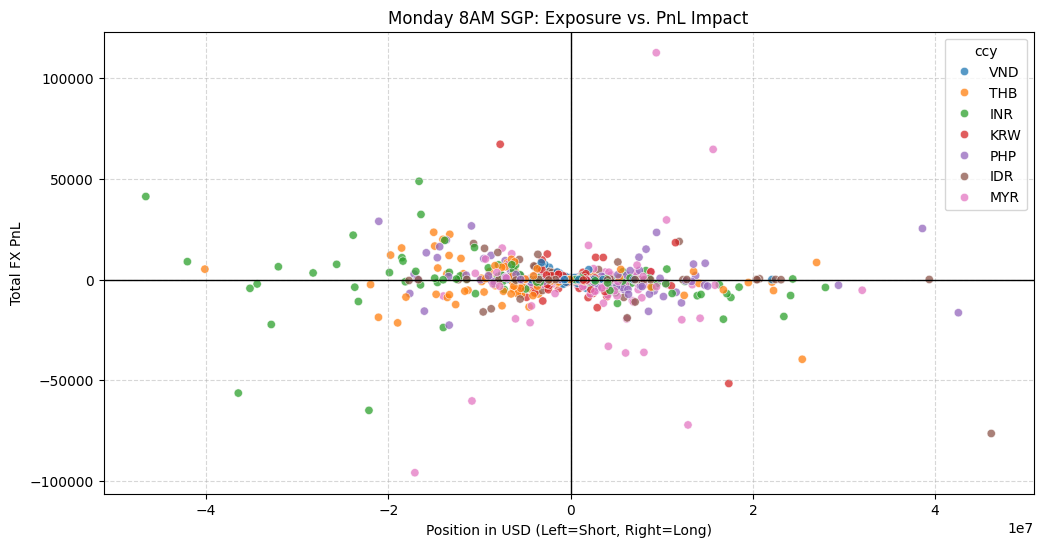

In [166]:
scatterplot(df, 0, 0)

In [205]:
scatterplot_interactive(df, 0, 0)

/var/folders/r6/lyd4620542j8pdy7dl_ccjtw0000gp/T/ipykernel_60409/1927043220.py:42: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [196]:
filter_df(df, 0, 0)

,ccy,hour_timestamp,hour_position,rate_to_usd,rate_to_gbp,total_fx_pnl,usd_rate,gbp_rate,position_in_USD,position_in_GBP
12,VND,2024-02-19,-2.876645e+10,0.000041,0.000032,2986.784502,24509.803922,30864.197531,-1.173671e+06,-9.320328e+05
27,THB,2024-02-19,-2.065141e+08,0.027810,0.022053,-470.189907,35.958547,45.345510,-5.743115e+06,-4.554234e+06
34,INR,2024-02-19,1.153629e+09,0.012046,0.009552,-8017.717385,83.015798,104.686829,1.389650e+07,1.101981e+07
35,KRW,2024-02-19,-7.483683e+07,0.000751,0.000595,98.974237,1332.267519,1680.107527,-5.617252e+04,-4.454288e+04
39,PHP,2024-02-19,-1.015898e+08,0.017868,0.014169,-1342.206816,55.964407,70.574120,-1.815257e+06,-1.439477e+06
...,...,...,...,...,...,...,...,...,...,...
126949,VND,2025-06-16,-1.734600e+10,0.000038,0.000028,-27.384257,26041.666667,35335.689046,-6.660865e+05,-4.908919e+05
126970,THB,2025-07-07,-1.319152e+08,0.030874,0.022617,1818.934769,32.390028,44.213942,-4.072710e+06,-2.983566e+06
127230,INR,2025-06-16,-1.204271e+09,0.011613,0.008571,-103.995815,86.108169,116.672500,-1.398556e+07,-1.032181e+07
127505,PHP,2025-07-07,8.334550e+08,0.017719,0.012980,8094.040411,56.436912,77.039228,1.476791e+07,1.081858e+07


In [234]:
sorted_df = df.sort_values(by='hour_timestamp', ascending=True)
sorted_df.loc[sorted_df['hour_timestamp'].dt.hour == 1]

,ccy,hour_timestamp,hour_position,rate_to_usd,rate_to_gbp,total_fx_pnl,usd_rate,gbp_rate,position_in_USD,position_in_GBP
103057,IDR,2024-01-01 01:00:00,1.119201e+11,0.000065,0.000051,13.664250,15408.320493,19607.843137,7.263618e+06,5.707927e+06
103074,PHP,2024-01-01 01:00:00,7.200599e+08,0.018055,0.014181,827.716530,55.387547,70.519375,1.300039e+07,1.021081e+07
103053,KRW,2024-01-01 01:00:00,-1.434661e+09,0.000776,0.000610,-2.658208,1288.161793,1639.881929,-1.113727e+06,-8.748564e+05
103052,THB,2024-01-01 01:00:00,-3.292640e+08,0.029291,0.023006,-589.055767,34.139946,43.467111,-9.644538e+06,-7.575015e+06
103030,MYR,2024-01-01 01:00:00,3.247240e+07,0.217675,0.170967,413.452893,4.594005,5.849082,7.068430e+06,5.551709e+06
...,...,...,...,...,...,...,...,...,...,...
122002,INR,2026-02-02 01:00:00,-1.589727e+09,0.010895,0.007952,-80.772844,91.787750,125.749783,-1.731960e+07,-1.264199e+07
123018,MYR,2026-02-02 01:00:00,1.081354e+07,0.253678,0.185167,-35.267383,3.942005,5.400530,2.743158e+06,2.002311e+06
123017,KRW,2026-02-02 01:00:00,-1.622154e+09,0.000688,0.000503,330.222729,1452.643812,1990.049751,-1.116690e+06,-8.151322e+05
122404,PHP,2026-02-02 01:00:00,2.896023e+08,0.016974,0.012390,-16.784102,58.913980,80.712204,4.915681e+06,3.588086e+06


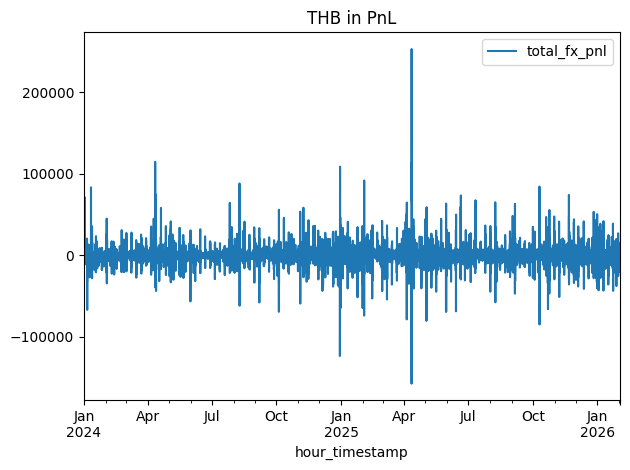

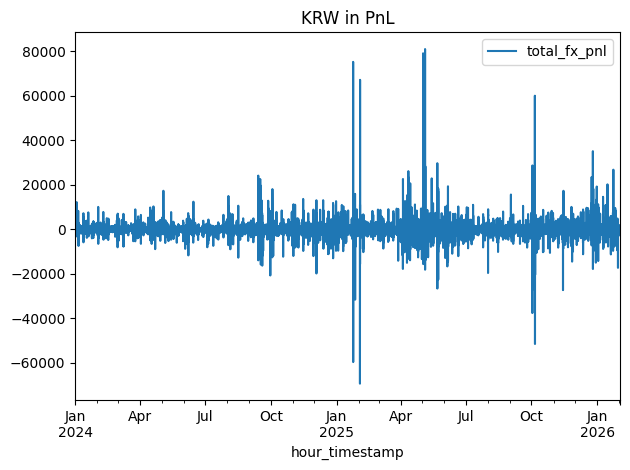

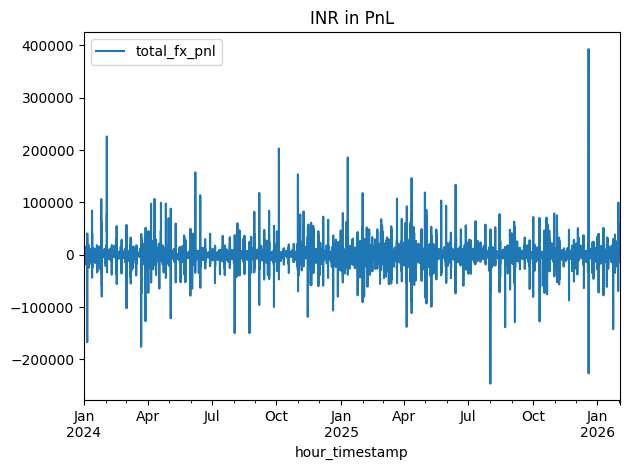

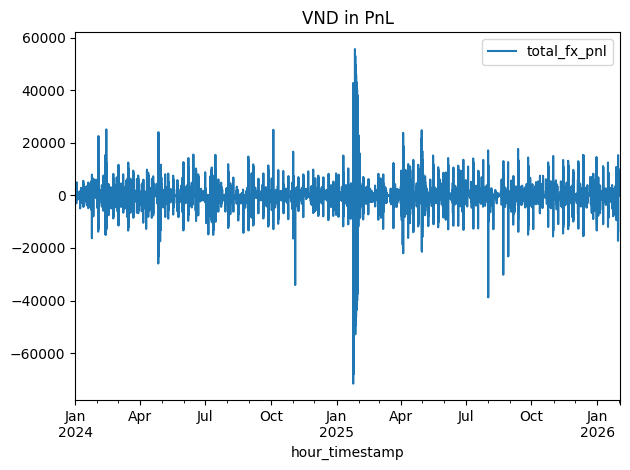

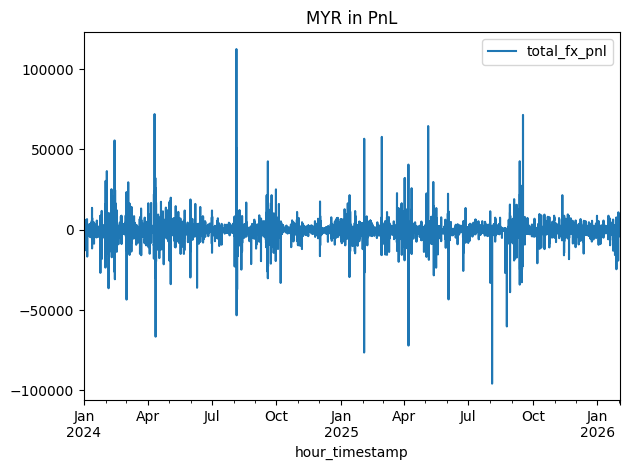

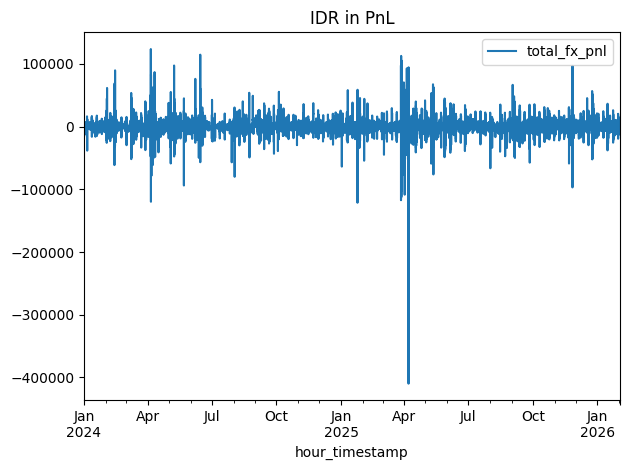

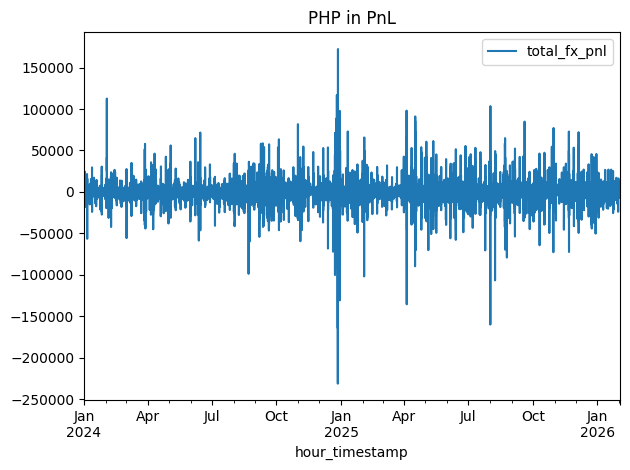

In [226]:
for ccy in df.ccy.unique():
    df.sort_values(by='hour_timestamp', ascending=True).loc[df['ccy'] == ccy].plot(x='hour_timestamp', y='total_fx_pnl')
    plt.title(f"{ccy} in PnL")
    plt.tight_layout()